<a href="https://colab.research.google.com/github/mdajad045/OIBSIP/blob/main/Task3_car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
print("All the library installed")

All the library installed


In [2]:

df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [5]:
df = df.dropna()

In [6]:
df = df.drop_duplicates()

## Visualizing data

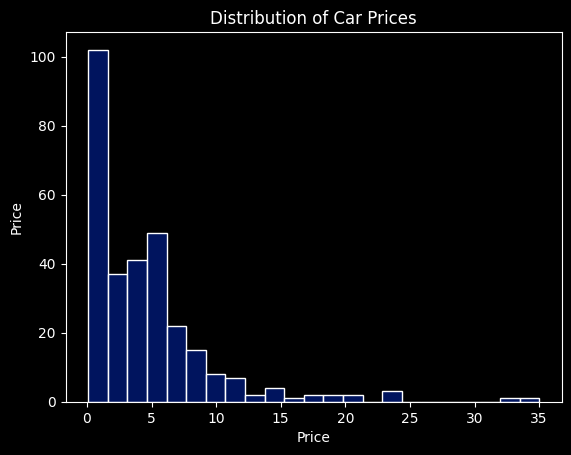

In [7]:
plt.style.use('dark_background')
sns.set_palette('dark')
sns.histplot(df['Selling_Price'])
plt.title('Distribution of Car Prices', color='white')
plt.xlabel('Price', color='white')
plt.ylabel('Price', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.show()

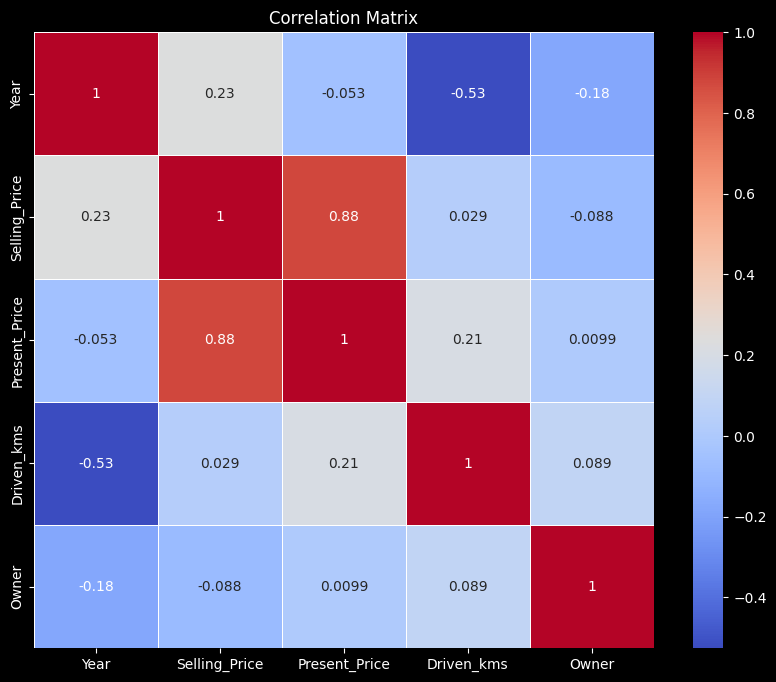

In [8]:
numeric_features = ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.show()

In [10]:
# Define features (X) and target (y)
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

In [11]:
label_encoder = LabelEncoder()
for col in X.columns:
  if X[col].dtype == 'object':
    X[col] = label_encoder.fit_transform(X[col])

## splitting data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Fitting the model

In [13]:

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [14]:

LinearRegression()

LinearRegression()

## Evaluating the Model

In [15]:

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
r2 = r2_score(y_test, predictions)

Mean Squared Error: 6.830668277839824
Root Mean Squared Error: 2.613554720651516


## Deployment and Prediction face

In [16]:
new_car_data = [[90, 2018, 6.0, 25000, 2, 0, 1, 0]]

new_car_df = pd.DataFrame(new_car_data, columns=X.columns)

# Since new_car_df already matches the structure of X, we can directly use it for prediction.
predicted_price = model.predict(new_car_df)
print('Predicted Price:', predicted_price)

Predicted Price: [5.59882059]
